<a href="https://colab.research.google.com/github/MotoShin/Adv360-Pro-ZMK/blob/V3.0/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
from __future__ import annotations
import argparse
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple
import math
import random
import statistics

import numpy as np
import matplotlib.pyplot as plt

# Environment

In [112]:
class BernoulliBanditEnv:
    def __init__(self, thetas: List[float], seed: Optional[int] = None):
        self.thetas = list(thetas)
        self.K = len(thetas)
        self.rng = random.Random(seed)

    def pull(self, arm: int) -> int:
        return 1 if self.rng.random() < self.thetas[arm] else 0

# Utilities

In [113]:
@dataclass
class Trace:
    mean: List[float]
    var: List[float]
    ess: List[float] # effective sample size = alpha + beta
    prior_frac: List[float] # fraction of ESS attributable to initial prior

def beta_mean_var(alpha: float, beta: float) -> Tuple[float, float]:
    m = alpha / (alpha + beta)
    v = (alpha * beta) / (((alpha + beta) ** 2) * (alpha + beta + 1))
    return m, v

def mean_var_to_ab(m: float, v: float, eps: float = 1e-12) -> Tuple[float, float]:
    m = min(max(m, eps), 1.0 - eps)
    v = max(v, eps)
    s = m * (1.0 - m) / v - 1.0
    s = max(s, 2.0 * eps)
    return m * s, (1.0 - m) * s

def greedy(values: List[float]) -> int:
    return int(np.argmax(values))

# Bayes Methods

## BaseEstimator

In [114]:
class BaseEstimator:
    def __init__(self, K: int = 8):
        self.ac = np.zeros(K)
        self.minimum_selection_number = 100

    def select(self, common_action_override: Optional[int] = None) -> int:
        if common_action_override is not None:
            action = common_action_override
        elif np.min(self.ac) < self.minimum_selection_number:
            inds = np.where(self.ac < self.minimum_selection_number)[0]
            action = np.random.choice(inds)
        else:
            action = greedy(self.posterior_mean())
        self.ac[action] += 1
        return action

    def update(self, x: int) -> None:
        raise NotImplementedError

    def posterior_mean(self) -> List[float]:
        raise NotImplementedError

    def posterior_var(self) -> List[float]:
        raise NotImplementedError

    def ess(self) -> List[float]:
        raise NotImplementedError

    def prior_fraction(self) -> List[float]:
        """Return the (approximate) fraction of ESS attributable to the initial prior.
        Interpretation differs by method; see subclasses for precise definitions."""
        raise NotImplementedError

    def get_success_counts(self):
        raise NotImplementedError

    def get_failure_counts(self):
        raise NotImplementedError

    def get_action_counts(self):
        raise NotImplementedError

## Standard Bayes

In [115]:
class StandardBayes(BaseEstimator):
    """Beta-Bernoulli with exact counts (no forgetting)."""
    def __init__(self, alpha0: float = 1.0, beta0: float = 1.0, K: int = 8):
        super().__init__(K)
        self.a0 = np.full(K, alpha0)
        self.b0 = np.full(K, beta0)
        self.a = np.full(K, alpha0)
        self.b = np.full(K, beta0)

    def update(self, action: int, x: float) -> None:
        self.a[action] += x
        self.b[action] += (1 - x)

    def posterior_mean(self) -> List[float]:
        return (self.a / (self.a + self.b))

    def posterior_var(self) -> List[float]:
        return ((self.a * self.b) / (((self.a + self.b) ** 2) * (self.a + self.b + 1)))

    def ess(self) -> List[float]:
        return (self.a + self.b)

    def prior_fraction(self) -> List[float]:
        # Exact fraction of prior pseudo-counts in current ESS
        return ((self.a0 + self.b0) / (self.a + self.b))

    def get_success_counts(self) -> List[float]:
        return self.a.copy()

    def get_failure_counts(self) -> List[float]:
        return self.b.copy()

    def get_action_counts(self) -> List[float]:
        return self.a + self.b - 2

    def get_init_belief(self):
        return {
            "a0": self.a0.copy(),
            "b0": self.b0.copy(),
            "sum": self.a0 + self.b0
        }

## Forgetful Bayes

In [116]:
class ForgetfulBayes(BaseEstimator):
    """
    Dynamic Belief Model (DBM) approximation per Zhang & Yu (2013).
    """
    def __init__(self, alpha0: float = 1.0, beta0: float = 1.0, K: int = 8, gamma: float = 0.8):
        super().__init__(K)
        self.a0 = np.full(K, alpha0)
        self.b0 = np.full(K, beta0)
        self.gamma = gamma
        self.a = np.full(K, alpha0)
        self.b = np.full(K, beta0)
        self.K = K

    def update(self, action: int, x: int) -> None:
        for k in range(self.K):
            prev_a = self.a[k]
            prev_b = self.b[k]
            if k == action:
                new_a = self.gamma * prev_a + x
                new_b = self.gamma * prev_b + (1 - x)
            else:
                new_a = self.gamma * prev_a + (1 - self.gamma) * self.a0[k]
                new_b = self.gamma * prev_b + (1 - self.gamma) * self.b0[k]

            self.a[k] = new_a
            self.b[k] = new_b

    def posterior_mean(self) -> List[float]:
        return self.a / (self.a + self.b)

    def posterior_var(self) -> List[float]:
        a, b = self.a, self.b
        return (a * b) / (((a + b) ** 2) * (a + b + 1))

    def ess(self) -> List[float]:
        return self.a + self.b

    def prior_fraction(self) -> List[float]:
        # Approximate contribution of the generic prior within the current Beta by
        # comparing to a hypothetical no-reset sequence (heuristic diagnostic).
        # Here we estimate it as the fraction of mass that would come from the
        # reset component in one step, scaled by 1/(1-γ) to reflect steady-state.
        return ((self.a0 + self.b0) / (self.a + self.b))

    def get_success_counts(self) -> List[float]:
        return self.a.copy()

    def get_failure_counts(self) -> List[float]:
        return self.b.copy()

    def get_action_counts(self):
        return self.a + self.b - 2

    def get_init_belief(self):
        return {
            "a0": self.a0.copy(),
            "b0": self.b0.copy(),
            "sum": self.a0 + self.b0
        }

## Attention-based Bayes

In [117]:
class ABB:
    def __init__(self, K: int = 8, S: float = 0.5):
        self.n = np.full(K, 1e-6)
        self.N = sum(self.n)
        self.V = np.full(K, 0.5)
        self.S = S
        rho = self.n / self.N
        self.RS = rho * (self.V - self.S)

        # Beyes比較のための変数
        self.a0 = np.ones(K)
        self.b0 = np.ones(K)
        self.a = np.ones(K)
        self.b = np.ones(K)
        self.succ = 0
        self.fail = 0

        # 序盤の選択制御のため
        self.ac = np.zeros(K)
        self.minimum_selection_number = 100

    def select(self, common_action_override: Optional[int] = None) -> int:
        if common_action_override is not None:
            action = common_action_override
        elif np.min(self.ac) < self.minimum_selection_number:
            inds = np.where(self.ac < self.minimum_selection_number)[0]
            action = np.random.choice(inds)
        else:
            action = greedy(self.posterior_mean())
        self.ac[action] += 1
        return action

    def update(self, action: int, x: int):
        alpha = 1 / (1 + self.n[action])
        self.V[action] = (1 - alpha) * self.V[action] + (x * alpha)
        self.n[action] += 1
        self.N += 1
        rho = self.n / self.N
        self.RS = rho * (self.V - self.S)

        # Bayes比較のための変数
        self.succ += x
        self.fail += (1 - x)
        self.a0 = self.S * (self.N - self.n)
        self.b0 = (1 - self.S) * (self.N - self.n)
        self.a = self.a0 + self.succ
        self.b = self.b0 + self.fail

    def posterior_mean(self) -> List[float]:
        return self.RS + self.S
        # return self.a / (self.a + self.b)

    def posterior_var(self) -> List[float]:
        return (self.a * self.b) / (((self.a + self.b) ** 2) * (self.a + self.b + 1))

    def ess(self) -> List[float]:
        return self.a + self.b

    def prior_fraction(self) -> List[float]:
        # Exact fraction of prior pseudo-counts in current ESS
        return (self.a0 + self.b0) / (self.a + self.b)

    def get_success_counts(self):
        return self.a.copy()

    def get_failure_counts(self):
        return self.b.copy()

    def get_action_counts(self):
        return self.n.copy()

    def get_init_belief(self):
        return {
            "a0": self.a0.copy(),
            "b0": self.b0.copy(),
            "sum": self.a0 + self.b0
        }

## Forgetful Q-Learning

In [118]:
class FQL:
    def __init__(self, K: int = 8, mu: float = 0.5, alpha: float = 0.1, alpha_f: float = 0.8):
        self.n = np.full(K, 1e-6)
        self.N = sum(self.n)
        self.V = np.full(K, mu)
        self.alpha = alpha
        self.alpha_forgetful = alpha_f
        self.mu = mu

        # Beyes比較のための変数
        self.a0 = np.full(K, mu / alpha_f)
        self.b0 = np.full(K, (1 - mu) / alpha_f)
        self.a = np.ones(K)
        self.b = np.ones(K)
        self.succ = 0
        self.fail = 0

        # 序盤の選択制御のため
        self.ac = np.zeros(K)
        self.minimum_selection_number = 100

    def select(self, common_action_override: Optional[int] = None) -> int:
        if common_action_override is not None:
            action = common_action_override
        elif np.min(self.ac) < self.minimum_selection_number:
            inds = np.where(self.ac < self.minimum_selection_number)[0]
            action = np.random.choice(inds)
        else:
            action = greedy(self.posterior_mean())
        self.ac[action] += 1
        return action

    def update(self, action: int, x: int):
        self.n[action] += 1
        self.N += 1
        action_num = len(self.V)
        for a in range(action_num):
            if a == action:
                self.V[a] = self.V[a] + self.alpha * (x - self.V[a])
                self.n[a] = self.n[a] + self.alpha * 1
                self.a[a] = (1 / self.alpha - 1) * self.V[a]
                self.b[a] = (1 / self.alpha - 1) * (1 - self.V[a])
            else:
                self.V[a] = self.V[a] + self.alpha_forgetful * (self.mu - self.V[a])
                self.n[a] = self.n[a] + self.alpha_forgetful * (1e-6 - self.n[a])
                self.a[a] = (1 / self.alpha_forgetful - 1) * self.V[a]
                self.b[a] = (1 / self.alpha_forgetful - 1) * (1 - self.V[a])

        # Bayes比較のための変数
        self.succ += x
        self.fail += (1 - x)

    def posterior_mean(self) -> List[float]:
        return self.V.copy()

    def posterior_var(self) -> List[float]:
        return (self.a * self.b) / (((self.a + self.b) ** 2) * (self.a + self.b + 1))

    def ess(self) -> List[float]:
        return self.a + self.b

    def prior_fraction(self) -> List[float]:
        # Exact fraction of prior pseudo-counts in current ESS
        return (self.a0 + self.b0) / (self.a + self.b)

    def get_success_counts(self):
        return self.a.copy()

    def get_failure_counts(self):
        return self.b.copy()

    def get_action_counts(self):
        return self.n.copy()

    def get_init_belief(self):
        return {
            "a0": self.a0.copy(),
            "b0": self.b0.copy(),
            "sum": self.a0 + self.b0
        }

# Runner

In [119]:
from os import initgroups
import random

@dataclass
class RunLog:
    thetas: List[float]
    chosen: List[int]
    means: List[List[float]] # [t][i]
    init_belief_a0: List[List[float]]
    init_belief_b0: List[List[float]]
    init_belief_exp: List[List[float]]
    action_counts: List[List[float]]
    trial_ratios: List[List[float]]

def run_bandit(
    K: int,
    T: int,
    thetas: Optional[List[float]] = None,
    seed: Optional[int] = None,
    alpha0: float = 1.2,
    beta0: float = 0.8,
    dbm_gamma: float = 0.95,
    S: float = 0.6,
    action_override_count: int = 100
) -> RunLog:
    rng = random.Random(seed)
    if thetas is None:
        # thetas = [rng.random() for _ in range(K)]
        thetas = [0.2, 0.8]
    env = BernoulliBanditEnv(thetas, seed=rng.randint(0, 10**9))
    # print("Thetas: {}".format(thetas))

    agents = {
        "Standard-Bayes": StandardBayes(alpha0, beta0, K),
        "Forgetful-Bayes": ForgetfulBayes(alpha0, beta0, K, dbm_gamma),
        "Attention-Bayes": ABB(K, S),
        "FQL": FQL(K, mu=S)
    }
    results = {
        "Standard-Bayes": None,
        "Forgetful-Bayes": None,
        "Attention-Bayes": None,
        "FQL": None
    }

    # 序盤に全てのエージェントが同じ行動を選択するように制御するためのList
    common_action_overrides = np.tile([0, 1], action_override_count)

    for label, agent in agents.items():
        print("Agent: {}".format(label))
        chosen, means, init_a0, init_b0, init_exp, ac, tratio = [], [], [], [], [], [], []
        for t in range(T):
            N = t + 1
            if t < action_override_count * K:
                action = agent.select(common_action_overrides[t])
            else:
                # select action
                action = agent.select()
            reward = env.pull(action)
            # update value
            agent.update(action, reward)
            chosen.append(action)

            # debug
            # print("Step: {}".format(t))
            # print("Action Count: {}".format(agent.get_action_counts()))
            # print("Chosen: {}".format(action))
            # print("Reward: {}".format(reward))
            # print("Mean: {}".format(agent.posterior_mean()))
            # print("Var: {}".format(agent.posterior_var()))
            # print("ESS: {}".format(agent.ess()))
            # print("Prior fraction: {}".format(agent.prior_fraction()))
            # print()

            # record
            means.append(agent.posterior_mean())
            init_belief_info = agent.get_init_belief()
            init_a0.append(init_belief_info["a0"])
            init_b0.append(init_belief_info["b0"])
            init_exp.append(init_belief_info["a0"] / init_belief_info["sum"])
            ac.append(agent.get_action_counts())
            tratio.append(np.array(agent.get_success_counts()) / (np.array(agent.get_success_counts()) + np.array(agent.get_failure_counts())))

        results[label] = RunLog(thetas, chosen, means, init_a0, init_b0, init_exp, ac, tratio)

    return results

# Main

In [120]:
results = run_bandit(
    K=2,
    T=1000
)

for label, log in results.items():
    print("{} Thetas: {}".format(label, np.array(log.thetas)))

Agent: Standard-Bayes
Agent: Forgetful-Bayes
Agent: Attention-Bayes
Agent: FQL
Standard-Bayes Thetas: [0.2 0.8]
Forgetful-Bayes Thetas: [0.2 0.8]
Attention-Bayes Thetas: [0.2 0.8]
FQL Thetas: [0.2 0.8]


# Plot

In [121]:
metrics_info = {
    'Action Counts': {
        'get_data': lambda log, arm_idx: np.array(log.action_counts)[:, arm_idx],
        'ylabel': 'Action Counts (Log Scale)'
    },
    'Initial Belief (a0)': {
        'get_data': lambda log, arm_idx: np.array(log.init_belief_a0)[:, arm_idx],
        'ylabel': 'Initial Belief (a0)'
    },
    'Initial Belief (b0)': {
        'get_data': lambda log, arm_idx: np.array(log.init_belief_b0)[:, arm_idx],
        'ylabel': 'Initial Belief (b0)'
    },
    'Initial Belief Exp': {
        'get_data': lambda log, arm_idx: np.array(log.init_belief_exp)[:, arm_idx],
        'ylabel': 'Initial Belief Exp (a0/(a0+b0))'
    },
    'Posterior Mean': {
        'get_data': lambda log, arm_idx: np.array(log.means)[:, arm_idx],
        'ylabel': 'Posterior Mean'
    }
}
print("Defined metrics_info dictionary for plotting.")

Defined metrics_info dictionary for plotting.


Graph: Action Counts, x: 0.7 - 1400.0, y: 0.7 - 1250.0
Graph: Action Counts, x: 0.7 - 1400.0, y: 0.7 - 1250.0
Graph: Initial Belief (a0), x: -49.0 - 1050.0, y: -27.0 - 567.0
Graph: Initial Belief (a0), x: -49.0 - 1050.0, y: -27.0 - 567.0
Graph: Initial Belief (b0), x: -49.0 - 1050.0, y: -27.0 - 567.0
Graph: Initial Belief (b0), x: -49.0 - 1050.0, y: -27.0 - 567.0
Graph: Initial Belief Exp, x: -48.95 - 1049.95, y: 0.5669999999999998 - 0.633
Graph: Initial Belief Exp, x: -48.95 - 1049.95, y: 0.5669999999999998 - 0.633
Graph: Posterior Mean, x: 0.7 - 1400.0, y: -0.03 - 1.0
Graph: Posterior Mean, x: 0.7 - 1400.0, y: -0.03 - 1.0
Multi-panel plot successfully regenerated and displayed with a single consolidated legend and adjusted marker start.


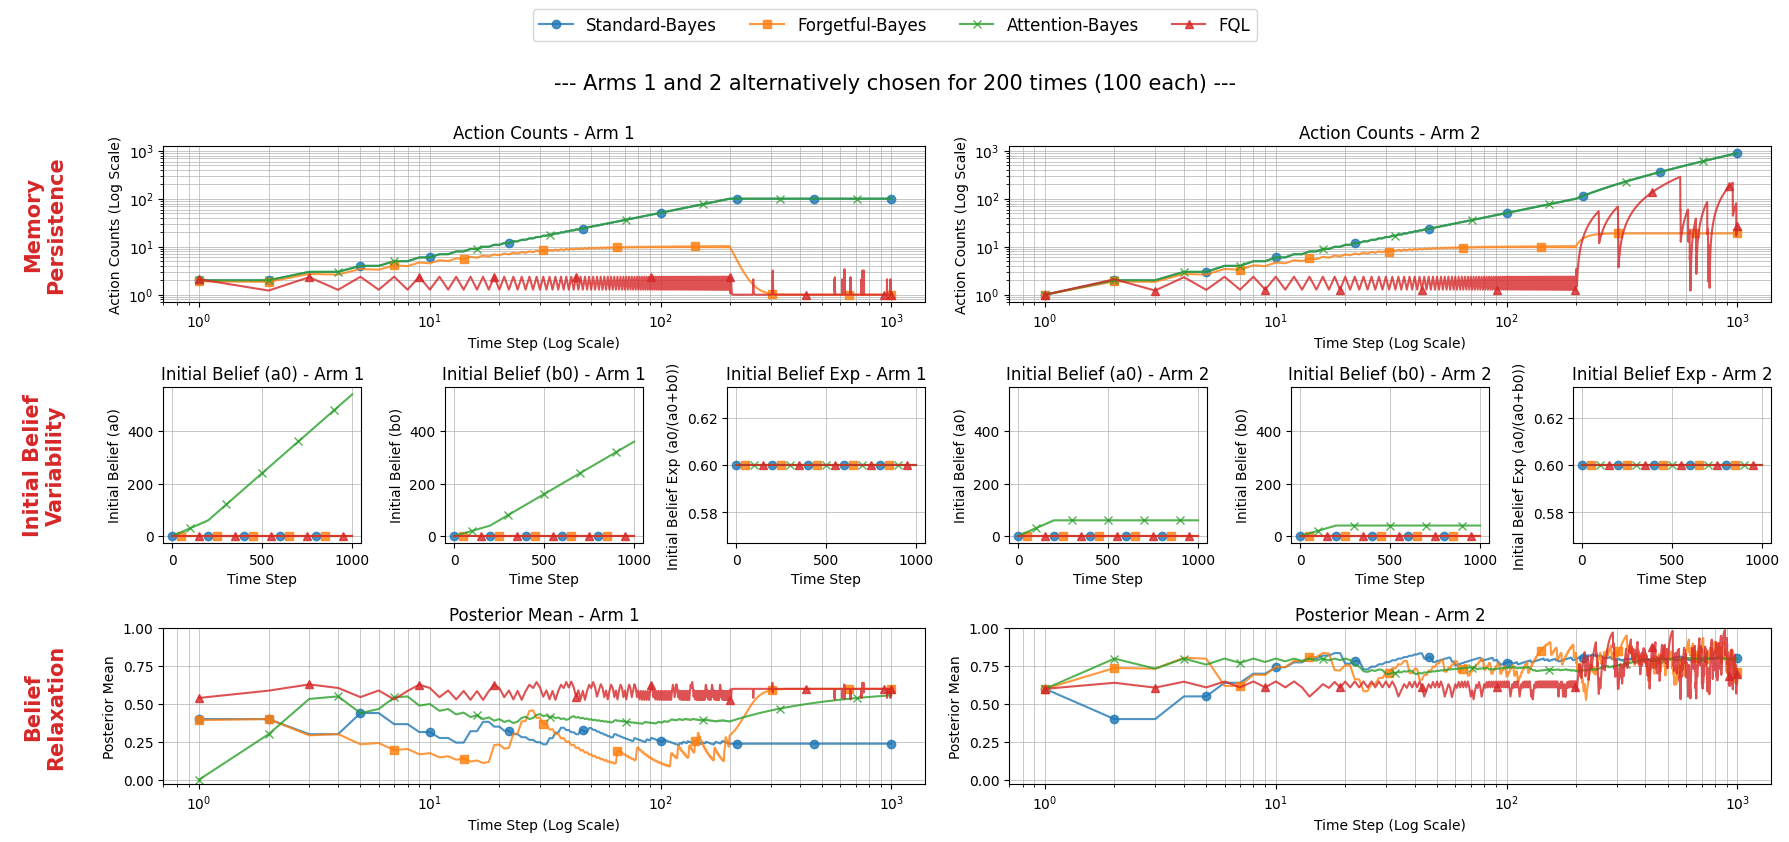

In [122]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as mpl_gridspec
import numpy as np

num_arms = len(results['Standard-Bayes'].thetas)
T = len(results['Standard-Bayes'].chosen)
agent_labels = ['Standard-Bayes', 'Forgetful-Bayes', 'Attention-Bayes', 'FQL']
line_markers = {
    'Standard-Bayes': 'o',
    'Forgetful-Bayes': 's',
    'Attention-Bayes': 'x',
    "FQL": "^"
}
markevery_styles = {
    'Standard-Bayes': (0, 200),
    'Forgetful-Bayes': (50, 200),
    'Attention-Bayes': (100, 200),
    "FQL": (150, 200)
}

# logスケールのマーカープロット位置の調整
base_marker = np.rint((np.logspace(0, 3, 10) - 1)).astype(int)
offset_ratio = 0.15  # 小さめが見た目が自然
x = np.arange(T)
base_x = x[base_marker]
# ログ空間ずらし後の x 値を求めてからインデックスに戻す関数
def to_index(x, vals):
    return np.array([np.argmin(np.abs(x - v)) for v in vals], dtype=int)
offsets = [
    1.0,                  # Standard-Bayes（ずらさない）
    10**offset_ratio,     # Forgetful-Bayes（右へ少しずらす）
    10**(-offset_ratio),   # Attention-Bayes（左へ少しずらす）
    10**(+offset_ratio * 2),   # FQL（さらに右）
]
# 系列ごとのマーカー列を作る
log_markevery_styles = {}
names = ['Standard-Bayes', 'Forgetful-Bayes', 'Attention-Bayes', 'FQL']
for name, off in zip(names, offsets):
    shifted_x = base_x * off               # ログ空間ずらし
    marker_idx = to_index(x, shifted_x)    # 実データインデックスへ変換
    log_markevery_styles[name] = marker_idx

log_time_steps = np.arange(1, T + 1)
kind_of_plots_num = 3

gs_total_cols = num_arms * kind_of_plots_num
gs_total_rows = kind_of_plots_num

fig = plt.figure(figsize=(3 * gs_total_cols, 3 * gs_total_rows))
width_ratios = [0.35] + [1.0] * gs_total_cols
gs = mpl_gridspec.GridSpec(
    gs_total_rows,
    gs_total_cols + 1,
    figure=fig,
    width_ratios=width_ratios
)

current_gs_row_idx = 0

axes = [[] for _ in range(num_arms)]
for j in range(num_arms):
    axes[j].append(fig.add_subplot(gs[0, j*3+1:(j+1)*3+1]))
    axes[j].append(fig.add_subplot(gs[1, j*3+1]))
    axes[j].append(fig.add_subplot(gs[1, j*3+2]))
    axes[j].append(fig.add_subplot(gs[1, j*3+3]))
    axes[j].append(fig.add_subplot(gs[2, j*3+1:(j+1)*3+1]))

# 各段の一番左に何のグラフかの説明を追加
graph_kinds = [
    "Memory\nPersistence",
    "Initial Belief\nVariability",
    "Belief\nRelaxation"
]
rowtop_axes = []
for i in range(gs_total_rows):
    ax = fig.add_subplot(gs[i, 0])
    ax.axis('off')
    ax.text(
        0.5, 0.5,
        graph_kinds[i],
        rotation=90,
        ha='center',
        va='center',
        fontsize=15,
        fontweight='bold',
        color='tab:red'
        )
    rowtop_axes.append(ax)

all_handles = []
all_labels = []

for i, (metric_name, metric_props) in enumerate(metrics_info.items()):
    for j in range(num_arms):
        ax = axes[j][i]

        xlabel_text = 'Time Step'

        for agent_label in agent_labels:
            log = results[agent_label]
            data = metric_props['get_data'](log, j)

            current_markevery = markevery_styles.get(agent_label)
            log_current_markevery = log_markevery_styles.get(agent_label)

            if metric_name == 'Action Counts':
                line, = ax.loglog(log_time_steps, data + 1, label=agent_label,
                          marker=line_markers[agent_label], markevery=log_current_markevery, alpha=0.8)
                ax.set_xlim(xmin=0.7, xmax=1400)
                ax.set_ylim(ymin=0.7, ymax=1250)
                xlabel_text = 'Time Step (Log Scale)'
            elif metric_name == 'Posterior Mean':
                line, = ax.semilogx(log_time_steps, data, label=agent_label,
                            marker=line_markers[agent_label], markevery=log_current_markevery, alpha=0.8)
                ax.set_xlim(xmin=0.7, xmax=1400)
                ax.set_ylim(ymin=-0.03, ymax=1.0)
                xlabel_text = 'Time Step (Log Scale)'
            elif metric_name == 'Initial Belief (a0)' or metric_name == 'Initial Belief (b0)':
                line, = ax.plot(log_time_steps, data, label=agent_label,
                        marker=line_markers[agent_label], markevery=current_markevery, alpha=0.8)
                ax.set_xlim(xmin=-49, xmax=1050)
                ax.set_ylim(ymin=-27, ymax=567)
            else:
                line, = ax.plot(log_time_steps, data, label=agent_label,
                        marker=line_markers[agent_label], markevery=current_markevery, alpha=0.8)

            if i == 0 and j == 0:
                all_handles.append(line)
                all_labels.append(agent_label)

        ax.set_title(f'{metric_name} - Arm {j+1}')
        ax.set_ylabel(metric_props['ylabel'])
        ax.grid(True, which="both", ls="-", lw=0.5)

        x_low, x_high = ax.get_xlim()
        y_low, y_high = ax.get_ylim()
        print("Graph: {}, x: {} - {}, y: {} - {}".format(metric_name, x_low, x_high, y_low, y_high))

        ax.set_xlabel(xlabel_text)

fig.legend(
    all_handles,
    all_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.97),
    ncol=len(agent_labels),
    fontsize='large'
)

fig.text(
    0.5, 0.89,
    '--- Arms 1 and 2 alternatively chosen for 200 times (100 each) ---',
    ha='center',
    va='top',
    fontsize=15
)

plt.tight_layout(rect=[0, 0.03, 1, 0.85])

# Explicitly show the figure object for robust display
fig.show()

print("Multi-panel plot successfully regenerated and displayed with a single consolidated legend and adjusted marker start.")